# LSTM and GRU: the gate that decides what a gradient survives

**Purpose.** Turn "gating fixes vanishing gradients" from a claim you have read into a number you have turned. You will print the LSTM's cell-state Jacobian, find the forget gate sitting on its diagonal, then set that gate by hand and watch the gradient arriving at the start of the sequence move by nearly four orders of magnitude.

**Prerequisites.** The vanilla RNN and backpropagation through time (BPTT), and ideally the sibling notebook [Recurrent neural networks](../01-recurrent-neural-networks/), which measures the decay this one repairs. Every LSTM and GRU equation, shape, and gradient is catalogued in the [reference](../../reference/lstm-and-gru/); the reasoning behind them is in the [explanation](../../explanation/lstm-and-gru/). This notebook *measures* what those pages derive.

**What you will be able to do by the end.**

- Read $\partial c^{\langle t\rangle} / \partial c^{\langle t-1\rangle}$ off a finite difference of the imported cell, and recognise the forget gate in it.
- Explain why an *elementwise* carry factor gives every hidden unit its own memory timescale — and show five of them spanning four orders of magnitude inside one cell.
- Set the forget gate deliberately and predict what it does to the gradient reaching $c^{\langle 0\rangle}$.
- Say what gating fixes and, precisely, what it does not.

**What this notebook is not.** It does not implement an LSTM or a GRU. Every forward pass, every gradient, the fixtures, and the sigmoid are imported from the hub's canonical NumPy modules — `dlhub.nn.sequence.lstm`, `.gru`, and `.min_gated` — the same code the reference documents and the finite-difference tests check.

**Runtime.** Under five seconds on a laptop CPU; nothing here is trained. **Seed.** `np.random.seed(1)`, set inside the shared `make_fixture()` and repeated in the setup cell, so every number below is reproducible.

### Where this fits

| Reader wants to | Go to |
| --- | --- |
| Learn it step by step | **This notebook** — you are here |
| Do it in a project | [Choose a gated cell](../../how-to/choose-a-gated-cell/) |
| Look up an equation or shape | [LSTM and GRU (reference)](../../reference/lstm-and-gru/) |
| Understand why it works | [LSTM and GRU (explanation)](../../explanation/lstm-and-gru/) |
| Learn by running it | **This notebook** — you are here |

## 1. Orient: one derivative is the whole argument

A vanilla RNN rebuilds its state from scratch at every step, so a gradient travelling back $k$ steps is multiplied by $k$ copies of the same recurrence Jacobian, $\operatorname{diag}(1 - a^2)\,W_{aa}$. That product is geometric, and the [previous notebook](../01-recurrent-neural-networks/) measured it decaying to nothing.

The LSTM adds a second state that is not rebuilt. The cell state $c^{\langle t\rangle}$ is *carried*, and the gates only decide when to intervene:

$$c^{\langle t\rangle} = \Gamma_u^{\langle t\rangle} \odot \tilde{c}^{\langle t\rangle} + \Gamma_f^{\langle t\rangle} \odot c^{\langle t-1\rangle}, \qquad a^{\langle t\rangle} = \Gamma_o^{\langle t\rangle} \odot \tanh\big(c^{\langle t\rangle}\big).$$

Nothing multiplies $c^{\langle t-1\rangle}$ except an elementwise gate. Differentiate that line and, holding the gates fixed, the entire argument for gated cells falls out as one equation:

$$\frac{\partial c^{\langle t\rangle}}{\partial c^{\langle t-1\rangle}} = \Gamma_f^{\langle t\rangle}.$$

No weight matrix. No saturating derivative. A vector of numbers in $(0, 1)$ that the network itself computed from its own input, and can compute differently at the next step. Everything below is an attempt to make that sentence concrete enough to distrust.

We work on the topic's **shared fixture**: the same seed, the same `float64` dtype, and the same dimensions $(n_x, n_a, n_y, m, T_x) = (3, 5, 2, 10, 4)$ that the LSTM's and GRU's finite-difference gradient checks use — and that the vanilla RNN module uses too, so the three cells are directly comparable. Nothing in this notebook draws a new weight.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dlhub.nn.sequence import sigmoid
from dlhub.nn.sequence.gru import gru_backward, gru_forward
from dlhub.nn.sequence.gru import make_fixture as gru_fixture
from dlhub.nn.sequence.lstm import lstm_backward, lstm_cell_forward, lstm_forward
from dlhub.nn.sequence.lstm import make_fixture as lstm_fixture
from dlhub.nn.sequence.min_gated import make_fixture as min_fixture
from dlhub.nn.sequence.min_gated import (
    min_gru_forward_parallel,
    min_gru_forward_sequential,
)
from dlhub.nn.sequence.rnn import compute_loss

np.random.seed(1)  # make_fixture seeds itself; pinned here so nothing below drifts.

fixture = lstm_fixture()
x = fixture["x"]  # inputs,          (n_x, m, T_x)
a0 = fixture["a0"]  # a^{<0>},         (n_a, m)
c0 = fixture["c0"]  # c^{<0>},         (n_a, m)
y = fixture["y"]  # one-hot targets, (n_y, m, T_x)
parameters = fixture["parameters"]
dims = fixture["dims"]

print("shared fixture:", dims)
print(f"x {x.shape}   a0 {a0.shape}   c0 {c0.shape}   y {y.shape}")
print("parameters:", ", ".join(sorted(parameters)))

shared fixture: {'n_x': 3, 'n_a': 5, 'n_y': 2, 'm': 10, 'T_x': 4}
x (3, 10, 4)   a0 (5, 10)   c0 (5, 10)   y (2, 10, 4)
parameters: Wc, Wf, Wo, Wu, Wy, bc, bf, bo, bu, by


## 2. The smallest meaningful example: one timestep

Four steps is already a sequence. One step is the unit a sequence is made of, and it is the smallest thing that can show the two features the vanilla RNN does not have: a second state, and gates that decided how it was built.

Run a single LSTM timestep on the fixture's first input. `lstm_cell_forward` returns the next hidden state, the next cell state, the softmax read-out, and a cache holding every intermediate quantity — including the three gates.

In [2]:
x_1 = x[:, :, 0]
a_1, c_1, y_hat_1, cache_1 = lstm_cell_forward(x_1, a0, c0, parameters)

print(f"a^<1> {a_1.shape}    c^<1> {c_1.shape}    y_hat^<1> {y_hat_1.shape}\n")
for name in ("gamma_f", "gamma_u", "gamma_o"):
    gate = cache_1[name]
    print(
        f"{name}:  min {gate.min():.4f}   mean {gate.mean():.4f}   max {gate.max():.4f}"
    )

print("\nforget gate for sequence 0 of the batch, unit by unit:")
print(np.round(cache_1["gamma_f"][:, 0], 4))

a^<1> (5, 10)    c^<1> (5, 10)    y_hat^<1> (2, 10)

gamma_f:  min 0.0002   mean 0.4655   max 0.9995
gamma_u:  min 0.0034   mean 0.5540   max 0.9891
gamma_o:  min 0.0042   mean 0.4678   max 0.9985

forget gate for sequence 0 of the batch, unit by unit:
[0.9467 0.9899 0.4487 0.073  0.2488]


Two states of shape `(n_a, m)` came back where a vanilla RNN returns one, and three gates spanning almost the whole of $(0, 1)$ decided the split. The forget gate for the first sequence in the batch reads roughly `[0.947, 0.990, 0.449, 0.073, 0.249]`: two units told to keep nearly everything, one told to discard nearly everything, two in between. Hold on to those five numbers.

## 3. Inspect: the forget gate *is* the Jacobian

The claim from step 1 needs nothing we have not already run. Nudge one unit of $c^{\langle 0\rangle}$ by $\pm 10^{-6}$, call the **imported** cell again, and difference the result: that is one column of $\partial c^{\langle 1\rangle} / \partial c^{\langle 0\rangle}$. Do it for each of the five units and the whole matrix is measured, for one sequence out of the batch of ten.

Two things to look for. Are the off-diagonal entries zero — does any unit's cell state reach any other's along this path? And is the diagonal the forget gate we just printed?

In [3]:
EXAMPLE = 0  # one sequence out of the batch of 10


def cell_state_jacobian(x_t, a_prev, c_prev, params, example=EXAMPLE, eps=1e-6):
    """
    Measure ``d c^{<t>} / d c^{<t-1>}`` by central differences, for one sequence.

    Every evaluation calls the imported ``lstm_cell_forward``; no LSTM
    mathematics is written here. Column ``j`` nudges unit ``j`` of the incoming
    cell state and reads the whole resulting change in the outgoing one.

    Parameters
    ----------
    x_t, a_prev, c_prev : np.ndarray
        This step's input and the two incoming states.
    params : dict[str, np.ndarray]
        The cell's weights and biases.
    example : int, optional
        Which sequence in the batch to differentiate.
    eps : float, optional
        Central-difference step.

    Returns
    -------
    np.ndarray
        The ``(n_a, n_a)`` Jacobian for that sequence.
    """
    n_a = c_prev.shape[0]
    jacobian = np.zeros((n_a, n_a))
    for j in range(n_a):
        c_plus, c_minus = c_prev.copy(), c_prev.copy()
        c_plus[j, example] += eps
        c_minus[j, example] -= eps
        _, c_up, _, _ = lstm_cell_forward(x_t, a_prev, c_plus, params)
        _, c_down, _, _ = lstm_cell_forward(x_t, a_prev, c_minus, params)
        jacobian[:, j] = (c_up[:, example] - c_down[:, example]) / (2 * eps)
    return jacobian


jacobian = cell_state_jacobian(x_1, a0, c0, parameters)
forget_1 = cache_1["gamma_f"][:, EXAMPLE]

print("measured d c^<1> / d c^<0>, sequence 0:")
print(np.round(jacobian, 6))
off_diagonal = jacobian - np.diag(np.diag(jacobian))
print(f"\nlargest off-diagonal entry      : {np.abs(off_diagonal).max():.1e}")
print(
    f"largest |diagonal - gamma_f|    : {np.abs(np.diag(jacobian) - forget_1).max():.1e}"
)

measured d c^<1> / d c^<0>, sequence 0:
[[0.946656 0.       0.       0.       0.      ]
 [0.       0.989856 0.       0.       0.      ]
 [0.       0.       0.448688 0.       0.      ]
 [0.       0.       0.       0.073041 0.      ]
 [0.       0.       0.       0.       0.248833]]

largest off-diagonal entry      : 0.0e+00
largest |diagonal - gamma_f|    : 1.3e-10


**What to notice.** Every off-diagonal entry is `0.0` — not small, exactly zero. No unit's memory can leak into another's along this path, because the only thing multiplying $c^{\langle t-1\rangle}$ is an elementwise product. And the diagonal agrees with `gamma_f` to about $10^{-10}$, which is the central-difference error, not a modelling error. The equation in step 1 is not an approximation.

Compare what the same measurement returns for a vanilla RNN: $\operatorname{diag}(1 - a^2)\,W_{aa}$ — dense, mixing every unit into every other, and *the same matrix at every step* because $W_{aa}$ is shared. Here it is a diagonal of five numbers the cell computed from its own input, free to be different at the next step.

So the fraction of a gradient that crosses $k$ steps along the cell path is a product of numbers rather than of matrices, $\prod_i \Gamma_f^{\langle i\rangle}$ — and there is one such product per unit. Run the whole four-step sequence and plot them.

loss on the fixture's own targets: 5.1318


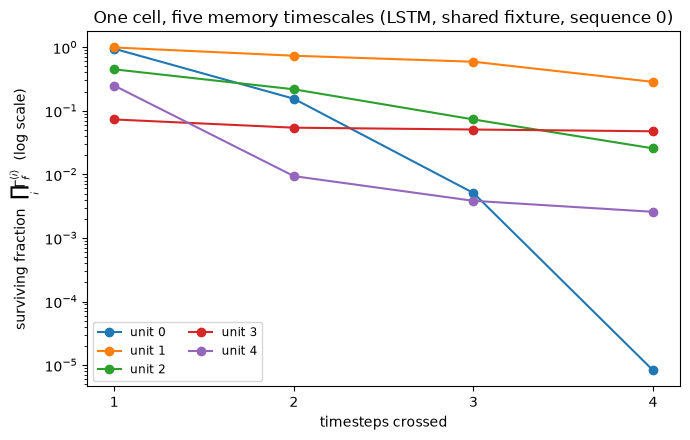

surviving fraction after all 4 steps, per unit:
[8.273545e-06 2.848646e-01 2.562428e-02 4.758579e-02 2.575996e-03]

spread between the best and worst unit: 34,431x
mean forget gate over the sequence     : 0.4920


In [4]:
a, c, y_hat, caches = lstm_forward(x, parameters, a0, c0)
print(f"loss on the fixture's own targets: {compute_loss(y_hat, y):.4f}")

forget = np.stack([cache["gamma_f"][:, EXAMPLE] for cache in caches], axis=-1)
carry = np.cumprod(forget, axis=-1)  # (n_a, T_x): surviving fraction after t steps
steps = np.arange(1, dims["T_x"] + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
for unit in range(dims["n_a"]):
    ax.semilogy(steps, carry[unit], "o-", label=f"unit {unit}")
ax.set_xlabel("timesteps crossed")
ax.set_ylabel(
    r"surviving fraction  $\prod_i \Gamma_f^{\langle i \rangle}$  (log scale)"
)
ax.set_title("One cell, five memory timescales (LSTM, shared fixture, sequence 0)")
ax.set_xticks(steps)
ax.legend(ncol=2, fontsize="small")
fig.tight_layout()
plt.show()

final = carry[:, -1]
print("surviving fraction after all 4 steps, per unit:")
print(np.array2string(final, precision=6, suppress_small=False))
print(f"\nspread between the best and worst unit: {final.max() / final.min():,.0f}x")
print(f"mean forget gate over the sequence     : {forget.mean():.4f}")

**What to notice.** Five lines, five slopes. Unit 1 ends at `0.285` — better than a quarter of a gradient crosses the entire sequence intact — while unit 0 ends at `8.3e-06`. That is a factor of about **34,000** between two units of the *same cell, at the same time, on the same input*. A vanilla RNN layer has exactly one decay rate, because it has exactly one $W_{aa}$; an elementwise gate gives every unit its own.

Now notice what the plot does **not** show: not one of those lines is flat. At the fixture's random initialisation the forget gates average about `0.5`, so the default behaviour of an untrained LSTM is still decay, at roughly $2^{-k}$. Gating does not fix vanishing gradients by existing. What it does is make the decay rate a quantity you can set — which is only worth anything if setting it works.

## 4. Vary exactly one thing: the forget gate

So set it. We remove the forget gate's dependence on the data by putting $W_f = 0$, which leaves $\Gamma_f = \sigma(\delta)$ for a single number $\delta$ of our choosing, identical for every unit and every step. **Everything else is untouched**: the other three gates, the read-out, the inputs, the targets, and both initial states are exactly what the fixture drew.

The measurement is $\lVert dc^{\langle 0\rangle}\rVert$ — the gradient BPTT delivers to the cell state *before the sequence began*, returned directly by `lstm_backward`. Sweep $\delta$ from $-8$ (gate shut, $\Gamma_f = 0.00034$) to $+8$ (gate open, $\Gamma_f = 0.99966$).

**Predict before you run the next cell.** The carry path multiplies by $\Gamma_f$ at each of the $T_x = 4$ steps, so the naive answer is that opening the gate rather than shutting it multiplies that gradient by

$$\left(\frac{0.99966}{0.00034}\right)^{4} \approx 8 \times 10^{13}.$$

Write down what you expect the measured ratio to be. More than that, about that, or less?

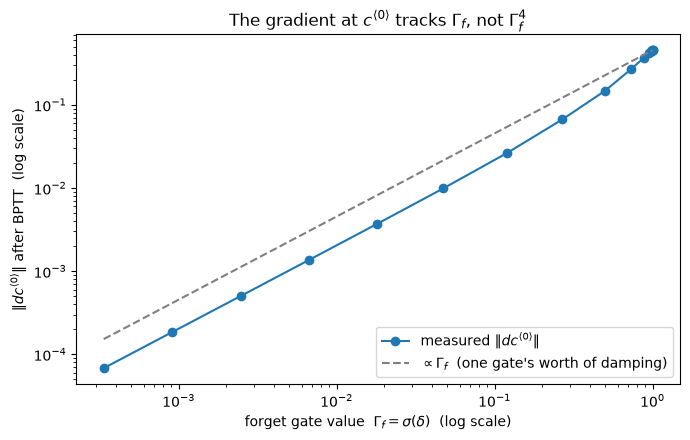

shut   Gamma_f = 0.00034   ||dc0|| = 6.8145e-05
open   Gamma_f = 0.99966   ||dc0|| = 4.5422e-01

measured ratio open / shut : 6,665
naive (Gamma_open / Gamma_shut)^T_x : 7.9e+13
slope of the log-log fit   : 1.11   (naive prediction: 4)


In [5]:
def gradient_reaching_c0(forget_logit):
    """
    ``||dc^{<0>}||`` after BPTT with the forget gate pinned at ``sigmoid(forget_logit)``.

    Zeroing ``Wf`` removes the gate's dependence on the data, so one scalar sets
    it everywhere. Every other array is the shared fixture, unchanged.

    Parameters
    ----------
    forget_logit : float
        The pre-activation the forget gate is pinned to.

    Returns
    -------
    float
        Norm of the gradient arriving at the initial cell state.
    """
    tuned = dict(parameters)
    tuned["Wf"] = np.zeros_like(parameters["Wf"])
    tuned["bf"] = np.full_like(parameters["bf"], forget_logit)
    _, _, _, tuned_caches = lstm_forward(x, tuned, a0, c0)
    return float(np.linalg.norm(lstm_backward(y, tuned_caches, tuned)["dc0"]))


logits = np.arange(-8.0, 8.1, 1.0)
gates = sigmoid(logits)
reaching = np.array([gradient_reaching_c0(z) for z in logits])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(
    gates,
    reaching,
    "o-",
    color="#1f77b4",
    label=r"measured $\|dc^{\langle 0 \rangle}\|$",
)
ax.loglog(
    gates,
    reaching[-1] * gates / gates[-1],
    "--",
    color="grey",
    label=r"$\propto \Gamma_f$  (one gate's worth of damping)",
)
ax.set_xlabel(r"forget gate value  $\Gamma_f = \sigma(\delta)$  (log scale)")
ax.set_ylabel(r"$\|dc^{\langle 0 \rangle}\|$ after BPTT  (log scale)")
ax.set_title(
    r"The gradient at $c^{\langle 0 \rangle}$ tracks $\Gamma_f$, not $\Gamma_f^4$"
)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

slope = np.polyfit(np.log(gates), np.log(reaching), 1)[0]
print(f"shut   Gamma_f = {gates[0]:.5f}   ||dc0|| = {reaching[0]:.4e}")
print(f"open   Gamma_f = {gates[-1]:.5f}   ||dc0|| = {reaching[-1]:.4e}")
print(f"\nmeasured ratio open / shut : {reaching[-1] / reaching[0]:,.0f}")
print(
    f"naive (Gamma_open / Gamma_shut)^T_x : {(gates[-1] / gates[0]) ** dims['T_x']:.1e}"
)
print(f"slope of the log-log fit   : {slope:.2f}   (naive prediction: {dims['T_x']})")

**What to notice.** The curve climbs monotonically over the whole sweep — the gate is unambiguously the knob — but the measured ratio is about **6,700**, ten orders of magnitude short of the naive $\Gamma_f^4$ answer, and the log-log slope is **1.1**, not 4. The measured points run *parallel* to the dashed $\propto \Gamma_f$ reference: one gate's worth of damping, not four. The constant gap between the two lines is a factor of about 2.2, and it is the other half of the story.

The reason is the difference between *a* gradient and a *long-range* gradient. With the gate open, all four steps' loss gradients reach $c^{\langle 0\rangle}$ essentially undamped and add together. With it shut, the later steps' gradients are annihilated long before they get near the start; what still arrives at $c^{\langle 0\rangle}$ is the **first** step's own gradient, which only ever had to cross one gate. So the ratio is one gate of damping, $1/0.00034 \approx 2{,}980$, times the $2.2\times$ from four steps' contributions accumulating instead of one — the gap in the figure. The long-range signal did not shrink by $10^{13}$; it vanished, and a purely local one took its place. Reading a gradient norm is not the same as reading how far a gradient travelled.

About 6,700 is the figure the [explanation](../../explanation/lstm-and-gru/) quotes for this experiment, reproduced here on the same fixture.

## 5. What this means, and what it does not

**What it means.** The per-step carry factor of a gated cell is a number the network computes, per unit and per step, with its own weights — not a spectral property of a matrix that is busy doing something else. You have measured it on the diagonal of a Jacobian, watched five units choose five different values of it, and moved the gradient at the start of a sequence by nearly four orders of magnitude by setting it by hand. That is also the whole argument for the oldest piece of LSTM folklore: **initialise $b_f$ positive**. It starts the cell at the right end of the curve you just plotted, before training has learned anything at all.

The GRU spells the same idea with one state instead of two. It keeps the old state with weight $1 - \Gamma_u$ and writes the candidate with weight $\Gamma_u$, so shutting its update gate is what opening the LSTM's forget gate is. Run the identical open-versus-shut experiment on both cells, each on its own shared fixture.

In [6]:
gru = gru_fixture()
x_g, a0_g, y_g, gru_parameters = gru["x"], gru["a0"], gru["y"], gru["parameters"]


def gru_gradient_reaching_a0(retain_logit):
    """
    ``||da^{<0>}||`` with the GRU's retain coefficient pinned at ``sigmoid(retain_logit)``.

    The GRU keeps old state with weight ``1 - Gamma_u``, so pinning the retain
    coefficient to ``sigmoid(z)`` means pinning ``Gamma_u`` to ``sigmoid(-z)``.

    Parameters
    ----------
    retain_logit : float
        Pre-activation of the retain coefficient ``1 - Gamma_u``.

    Returns
    -------
    float
        Norm of the gradient arriving at the initial hidden state.
    """
    tuned = dict(gru_parameters)
    tuned["Wu"] = np.zeros_like(gru_parameters["Wu"])
    tuned["bu"] = np.full_like(gru_parameters["bu"], -retain_logit)
    _, _, tuned_caches = gru_forward(x_g, tuned, a0_g)
    return float(np.linalg.norm(gru_backward(y_g, tuned_caches, tuned)["da0"]))


rows = (
    (
        "LSTM   dc^<0>, carried by Gamma_f",
        gradient_reaching_c0(8.0),
        gradient_reaching_c0(-8.0),
    ),
    (
        "GRU    da^<0>, carried by 1 - Gamma_u",
        gru_gradient_reaching_a0(8.0),
        gru_gradient_reaching_a0(-8.0),
    ),
)
print(f"{'':40s}{'carry open':>13s}{'carry shut':>13s}{'ratio':>10s}")
for label, carry_open, carry_shut in rows:
    print(
        f"{label:40s}{carry_open:13.4e}{carry_shut:13.4e}{carry_open / carry_shut:10.1f}"
    )

                                           carry open   carry shut     ratio
LSTM   dc^<0>, carried by Gamma_f          4.5422e-01   6.8145e-05    6665.5
GRU    da^<0>, carried by 1 - Gamma_u      4.5531e-01   1.3338e-01       3.4


**Reading the table.** Opened, the two cells carry almost identically — `0.4542` against `0.4553`. Shut, they part company completely. The LSTM's $c^{\langle 0\rangle}$ is reachable *only* through forget gates, so shutting them leaves $6.8 \times 10^{-5}$: the channel is dedicated, and it closes as cleanly as it opens. The GRU's $a^{\langle 0\rangle}$ is also read by the candidate and by both gates, so shutting the carry still leaves `0.133` arriving — along routes that look exactly like a vanilla RNN's, a weight matrix followed by a saturating derivative. One state doing several jobs is the GRU's economy and its price. Which cell is *better* is not settled by this measurement or any other; [choose a gated cell](../../how-to/choose-a-gated-cell/) covers how to decide.

**What it does not mean.** Three caveats, each of which this notebook has already brushed against.

- **"Holding the gates fixed" is a real clause.** The gates are themselves functions of $a^{\langle t-1\rangle}$, so vanilla-RNN-like routes survive in both cells. The step-3 Jacobian is exactly diagonal across *one* step; the same measurement across four steps is not.
- **The product is still geometric.** $\prod_i \Gamma_f^{\langle i\rangle}$ is still strictly less than one. A gate held at `0.9` retains $2.7 \times 10^{-5}$ of a gradient after 100 steps; a gate at `0.999` retains 90%. Gating makes long-range memory **reachable**, not automatic — which regime a trained cell lands in is a fact about its learned parameters, not a guarantee from the architecture.
- **Nothing here touches exploding gradients, or cost.** Clipping is still the remedy for the first. As for the second, the recurrence is still *serial*: $T_x$ steps, each waiting for the last. The 2024 minimal variants attack exactly that, by deleting the gates' dependence on $a^{\langle t-1\rangle}$ — which leaves $a^{\langle t\rangle} = \alpha^{\langle t\rangle} \odot a^{\langle t-1\rangle} + \beta^{\langle t\rangle}$, a first-order linear recurrence an associative scan resolves in $\lceil \log_2 T_x \rceil$ rounds instead of $T_x$. One cell is enough to see that the two routes compute the same function.

In [7]:
minimal = min_fixture()
x_min, a0_min, min_gru_parameters = minimal["x"], minimal["a0"], minimal["min_gru"]

serial = min_gru_forward_sequential(x_min, min_gru_parameters, a0_min)
scanned = min_gru_forward_parallel(x_min, min_gru_parameters, a0_min)

print(f"minGRU over T_x = {minimal['dims']['T_x']} steps (odd, and not a power of two)")
print(
    f"sequential loop vs parallel scan, max abs difference: {np.abs(serial - scanned).max():.1e}"
)

minGRU over T_x = 7 steps (odd, and not a power of two)
sequential loop vs parallel scan, max abs difference: 4.4e-16


Same function, different association order, agreeing to floating-point noise. What that buys and what it costs — the reset gate, the output gate, and the candidate's $\tanh$ are all gone — is the [explanation](../../explanation/lstm-and-gru/)'s subject, not this notebook's.

### Key Takeaways

1. $\partial c^{\langle t\rangle} / \partial c^{\langle t-1\rangle} = \Gamma_f^{\langle t\rangle}$ is measurable, not merely assertable: differencing the imported cell returns a matrix whose off-diagonal entries are exactly zero and whose diagonal is the forget gate to finite-difference precision.
2. Because that factor is *elementwise*, every hidden unit gets its own memory timescale. On the shared fixture five units in one cell span a factor of 34,000 in how much gradient they carry across four steps.
3. Because it is *computed*, the carry rate is a knob. Pinning the forget gate open rather than shut moves the gradient reaching $c^{\langle 0\rangle}$ by about 6,700x, with every other array held fixed — which is the argument for initialising $b_f$ positive.
4. Measured ratios need reading. The 6,700x is one gate's worth of damping and an accumulation factor, not $\Gamma_f^{4}$: shutting the carry does not shrink the long-range signal, it replaces it with a local one.
5. At random initialisation the forget gates average 0.5, so an untrained LSTM still decays at roughly $2^{-k}$. Gating makes long memory reachable, not automatic.
6. The LSTM's carry is a dedicated channel and closes to $6.8 \times 10^{-5}$; the GRU's shares one state with the candidate and the gates, so it never drops below `0.133`. Open, the two carry the same.
7. Gating leaves exploding gradients (clip them) and serial cost (minGRU/minLSTM trade gate expressiveness for a parallel scan) exactly where it found them.

Continue with the [explanation](../../explanation/lstm-and-gru/) for the full derivation and the GRU-versus-LSTM argument, the [reference](../../reference/lstm-and-gru/) for every equation, shape, and gradient in lookup form, or [choose a gated cell](../../how-to/choose-a-gated-cell/) to put one into a project.